##Task - 1

In [20]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report

In [21]:
train_dir = "/content/drive/MyDrive/AI and ML/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI and ML/FruitinAmazon/test"

In [22]:
# Verifying Dataset Directory
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

if not class_names:
    print("No class directories found!")
else:
    print(f"Found {len(class_names)} classes:", class_names)

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [23]:
# Checking Corrupted Images
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            with Image.open(img_path) as img:
                img.verify()
        except (IOError, UnidentifiedImageError):
            corrupted_images.append(img_path)

if corrupted_images:
    print("Corrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")

No corrupted images found.


In [24]:
# Checking Class Distribution
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png','.jpg','.jpeg'))]
    class_counts[class_name] = len(images)

print("\nClass Distribution:")
for k, v in class_counts.items():
    print(k, ":", v)


Class Distribution:
acai : 15
cupuacu : 15
graviola : 15
guarana : 15
pupunha : 15
tucuma : 15


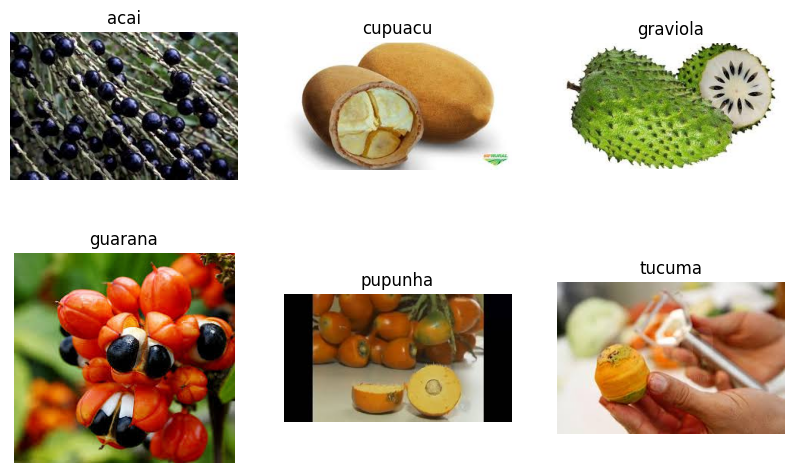

In [25]:
# Image visualization
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)
    if images:
        img_path = os.path.join(class_path, random.choice(images))
        selected_images.append(img_path)
        selected_labels.append(class_name)

plt.figure(figsize=(10,6))
for i in range(len(selected_images)):
    plt.subplot(2,3,i+1)
    img = mpimg.imread(selected_images[i])
    plt.imshow(img)
    plt.title(selected_labels[i])
    plt.axis("off")
plt.show()

In [26]:
# Loading Train and Validation Dataset
image_size = (224, 224)
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [27]:
# Checking Dataset Shape
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


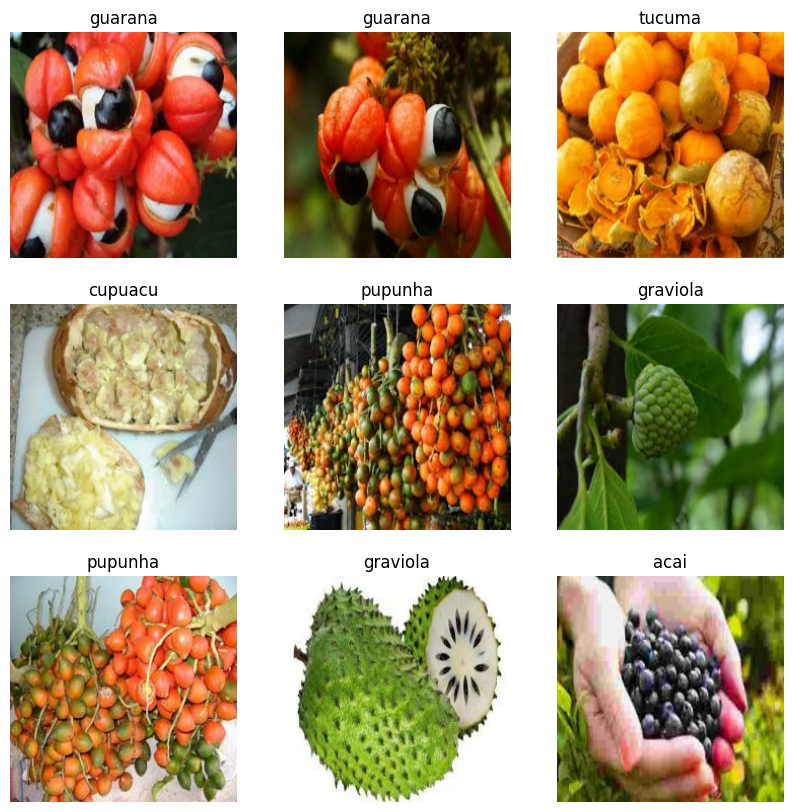

In [28]:
#  Visualizing Training Data
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [29]:
# data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

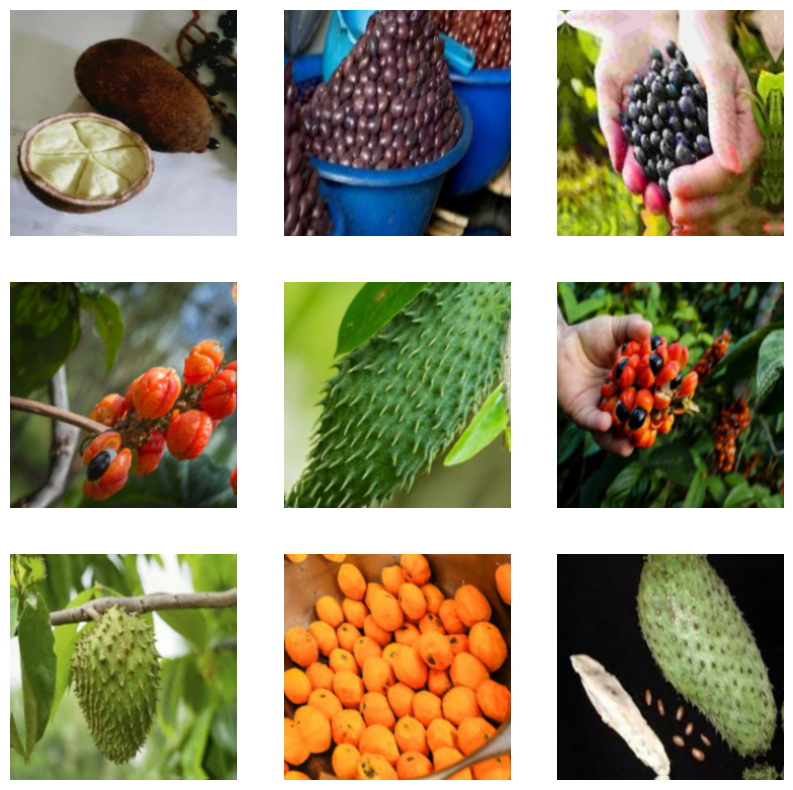

In [30]:
# Visualizing Augmented Images
plt.figure(figsize=(10,10))
for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")
plt.show()

CNN model

In [31]:
# Define Model with BatchNorm & Dropout
model = Sequential([
    layers.Input(shape=(224,224,3)),
    data_augmentation,
    layers.Rescaling(1./255),

    Conv2D(32,(3,3),padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(64,(3,3),padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(128,(3,3),padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Flatten(),

    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

In [32]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           77

 Total params: 12,940,614 (49.36 MB)

 Trainable params: 12,939,910 (49.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [34]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
# Train Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.2639 - loss: 2.3833 - val_accuracy: 0.0556 - val_loss: 3.0888
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.5278 - loss: 1.4606 - val_accuracy: 0.1667 - val_loss: 2.5591
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 7s/step - accuracy: 0.5694 - loss: 1.2972 - val_accuracy: 0.1667 - val_loss: 1.9421
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.5972 - loss: 1.2349 - val_accuracy: 0.2778 - val_loss: 1.7750
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.6806 - loss: 0.9745 - val_accuracy: 0.2222 - val_loss: 1.8733
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.5972 - loss: 0.9760 - val_accuracy: 0.2222 - val_loss: 1.9558
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.6667 - loss: 0.8488 - val_accuracy: 0.2222 - val_loss: 2.0223
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.8056 - loss: 0.6405 - val_accuracy: 0.2222 - val_loss: 2.1215
Epoch 9/

In [36]:
# Evaluate Model
cnn_loss, cnn_acc = model.evaluate(val_ds)
print("CNN Accuracy:", cnn_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step - accuracy: 0.1111 - loss: 3.1351
CNN Accuracy: 0.1111111119389534


In [38]:
# Classification Report
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         1
     cupuacu       0.11      1.00      0.20         2
    graviola       0.00      0.00      0.00         3
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         4
      tucuma       0.00      0.00      0.00         3

    accuracy                           0.11        18
   macro avg       0.02      0.17      0.03        18
weighted avg       0.01      0.11      0.02        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##Task-2

In [39]:
#Loading Pretrained Model
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [40]:
# Freezing Layers
for layer in base_model.layers:
    layer.trainable = False

In [41]:
# Adding Custom Layers
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

In [42]:
# Creating Model
from tensorflow.keras.models import Model

vgg_model = Model(inputs=base_model.input, outputs=outputs)

In [43]:
# Compile Model
vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
# Train Model
history_vgg = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 17s/step - accuracy: 0.2500 - loss: 11.0026 - val_accuracy: 0.3333 - val_loss: 3.2404
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 75s 15s/step - accuracy: 0.3333 - loss: 5.4701 - val_accuracy: 0.4444 - val_loss: 3.2658
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 21s/step - accuracy: 0.4722 - loss: 4.1815 - val_accuracy: 0.5556 - val_loss: 2.1348
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 21s/step - accuracy: 0.6111 - loss: 2.5185 - val_accuracy: 0.7222 - val_loss: 1.8846
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 21s/step - accuracy: 0.7917 - loss: 1.0093 - val_accuracy: 0.6667 - val_loss: 2.1068
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 16s/step - accuracy: 0.7083 - loss: 1.2318 - val_accuracy: 0.5556 - val_loss: 2.2164
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 16s/step - accuracy: 0.7917 - loss: 1.3125 - val_accuracy: 0.6667 - val_loss: 2.1410
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 83s 16s/step - accuracy: 0.8889 - loss: 0.4681 - val_accuracy: 0.7222 - val_loss: 2.1067

In [45]:
# Evaluate Model
vgg_loss, vgg_acc = vgg_model.evaluate(val_ds)
print("VGG16 Accuracy:", vgg_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.6667 - loss: 2.0927
VGG16 Accuracy: 0.6666666865348816


In [46]:
# Classification Report
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = vgg_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         1
     cupuacu       0.50      0.50      0.50         2
    graviola       1.00      1.00      1.00         3
     guarana       0.67      0.80      0.73         5
     pupunha       0.50      0.50      0.50         4
      tucuma       1.00      0.67      0.80         3

    accuracy                           0.67        18
   macro avg       0.61      0.58      0.59        18
weighted avg       0.69      0.67      0.67        18



In [47]:
# Comparison
print("CNN Accuracy:", cnn_acc)
print("VGG Accuracy:", vgg_acc)

CNN Accuracy: 0.1111111119389534
VGG Accuracy: 0.6666666865348816
